In [1]:
# ==========================================
# SPAM EMAIL DETECTION
# Importar librerías
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [2]:
# ==========================================
# Cargar dataset
# ==========================================

df = pd.read_csv("../data/spam.csv", encoding="latin-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
# ==========================================
# Información del dataset
# ==========================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [4]:
# ==========================================
# Eliminar columnas vacías
# ==========================================

df = df[['v1', 'v2']]

df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
# ==========================================
# Renombrar columnas
# ==========================================

df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
# ==========================================
# Valores nulos
# ==========================================

df.isnull().sum()

label      0
message    0
dtype: int64

In [7]:
# ==========================================
# Cantidad de clases
# ==========================================

df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [8]:
# ==========================================
# Convertir etiquetas a números
# ham = 0
# spam = 1
# ==========================================

df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
# ==========================================
# Variables independientes y objetivo
# ==========================================

X = df['message']
y = df['label']

print("Cantidad de mensajes:", len(X))
print("Cantidad de etiquetas:", len(y))

Cantidad de mensajes: 5572
Cantidad de etiquetas: 5572


In [10]:
# ==========================================
# Dividir datos
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Entrenamiento:", len(X_train))
print("Prueba:", len(X_test))

Entrenamiento: 4457
Prueba: 1115


In [11]:
# ==========================================
# Vectorización TF-IDF
# ==========================================

vectorizer = TfidfVectorizer(stop_words='english')

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

print("Vectorización completada")
print(X_train.shape)
print(X_test.shape)

Vectorización completada
(4457, 7472)
(1115, 7472)


In [12]:
# ==========================================
# Entrenar modelo Naive Bayes
# ==========================================

model = MultinomialNB()

model.fit(X_train, y_train)

print("✅ Modelo entrenado correctamente")

✅ Modelo entrenado correctamente


In [13]:
# ==========================================
# Predicciones
# ==========================================

y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 1 0 0 0 0 0]


In [14]:
# ==========================================
# Accuracy
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9668


In [15]:
# ==========================================
# Classification Report
# ==========================================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



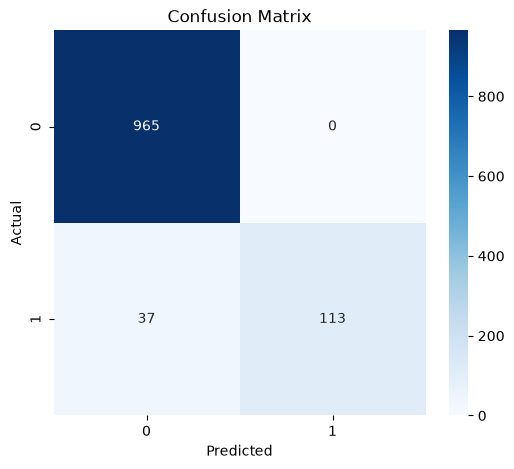

In [16]:
# ==========================================
# Matriz de confusión
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [17]:
# ==========================================
# Guardar modelo y vectorizador
# ==========================================

joblib.dump(model, "../models/spam_classifier.pkl")
joblib.dump(vectorizer, "../models/vectorizer.pkl")

print("✅ Modelo guardado correctamente")

✅ Modelo guardado correctamente


In [18]:
# ==========================================
# Prueba del modelo
# ==========================================

mensaje = ["Congratulations! You have won a FREE iPhone. Click here now!"]

mensaje_vectorizado = vectorizer.transform(mensaje)

prediccion = model.predict(mensaje_vectorizado)

if prediccion[0] == 1:
    print("📩 SPAM")
else:
    print("📨 HAM")

📩 SPAM


In [19]:
mensaje = ["Hi Sebastian, are you coming to the gym today?"]

mensaje_vectorizado = vectorizer.transform(mensaje)

prediccion = model.predict(mensaje_vectorizado)

if prediccion[0] == 1:
    print("📩 SPAM")
else:
    print("📨 HAM")

📨 HAM
